
## Project Overview

This project focuses on building a machine learning–based classification system to predict whether an insurance policyholder is likely to file an insurance claim. While the problem appears simple at first glance, it becomes challenging due to the limited number of samples and the slight class imbalance present in the dataset. These characteristics closely resemble real-world insurance data, where claim events are relatively rare compared to non-claim cases.

The goal of this project is to overcome these challenges and develop a robust predictive model capable of accurately classifying claim and non-claim instances.




## Dataset Description

The project uses the Sample Insurance Claim Prediction Dataset, which is based on the Medical Cost Personal Dataset and enhanced with updated sample values. Each record represents an individual policyholder with demographic, lifestyle, and insurance-related attributes.

## Features included in the dataset:

age: Age of the policyholder

sex: Gender of the policyholder (female = 0, male = 1)

bmi: Body Mass Index (kg/m²), an indicator of body weight relative to height

steps: Average walking steps per day

children: Number of dependents covered by the policy

smoker: Smoking status (non-smoker = 0, smoker = 1)

region: Residential area in the US

northeast = 0, northwest = 1, southeast = 2, southwest = 3

charges: Individual medical costs billed by health insurance

insuranceclaim: Target variable indicating claim status (yes = 1, no = 0)


## Problem Statement

The task is to predict whether a policyholder will file an insurance claim based on the available features. Since claim cases are fewer than non-claim cases, traditional accuracy-based modeling may lead to biased results, making it essential to use proper evaluation techniques.

## Stractegic Plan of Action:

We aim to solve the problem statement by creating a plan of action, Here are some of the necessary steps:

Data Exploration
Exploratory Data Analysis (EDA)
Data Pre-processing
Data Manipulation
Feature Selection/Extraction
Predictive Modelling
Project Outcomes & Conclusion

In [85]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math
from imblearn.over_sampling import SMOTE
import lazypredict
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.svm import SVC
from scipy.stats import loguniform, randint
from tqdm import tqdm
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier






# Display options.
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

In [70]:
path = "C:\\Users\\utkar\\Downloads\\insurance.csv"
df = pd.read_csv(path)

target = 'insuranceclaim'
labels = ['Claimed','Not Claimed']
features = [i for i in df.columns.values if i not in [target]]

original_df = df.copy(deep=True)
display(df.head())

print('\n\033[1mInference:\033[0m The Datset consists of {} features & {} samples.'.format(df.shape[1], df.shape[0]))

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1



Inference: The Datset consists of 8 features & 1338 samples.


In [32]:
df.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


In [33]:
df.tail()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
1333,50,1,30.97,3,0,1,10600.5483,0
1334,18,0,31.92,0,0,0,2205.9808,1
1335,18,0,36.85,0,0,2,1629.8335,1
1336,21,0,25.80,0,0,3,2007.9450,0
1337,61,0,29.07,0,1,1,29141.3603,1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   age             int64  
 1   sex             int64  
 2   bmi             float64
 3   children        int64  
 4   smoker          int64  
 5   region          int64  
 6   charges         float64
 7   insuranceclaim  int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
sex,1338.0,0.505232,0.500160,0.0000,0.00000,1.000,1.000000,1.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
smoker,1338.0,0.204783,0.403694,0.0000,0.00000,0.000,0.000000,1.00000
region,1338.0,1.515695,1.104885,0.0000,1.00000,2.000,2.000000,3.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801
insuranceclaim,1338.0,0.585202,0.492871,0.0000,0.00000,1.000,1.000000,1.00000


In [36]:
#Checking number of unique rows in each feature

df.nunique().sort_values()

sex                  2
smoker               2
insuranceclaim       2
region               4
children             6
age                 47
bmi                548
charges           1337
dtype: int64

In [37]:
#Checking number of unique rows in each feature

nu = df[features].nunique().sort_values()
nf = []; cf = []; nnf = 0; ncf = 0; #numerical & categorical features

for i in range(df[features].shape[1]):
    if nu.values[i]<=7:cf.append(nu.index[i])
    else: nf.append(nu.index[i])

print('\n\033[1mInference:\033[0m The Datset has {} numerical & {} categorical features.'.format(len(nf),len(cf)))


Inference: The Datset has 3 numerical & 4 categorical features.


In [38]:
#Checking the stats of all the columns

display(df.describe())

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265,0.585202
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237,0.492871
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900,0.000000
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000,1.000000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515,1.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010,1.000000


Inference: The stats seem to be fine, let us gain more undestanding by visualising the dataset.

## 2. Exploratory Data Analysis (EDA)

            Target Variable Distribution           


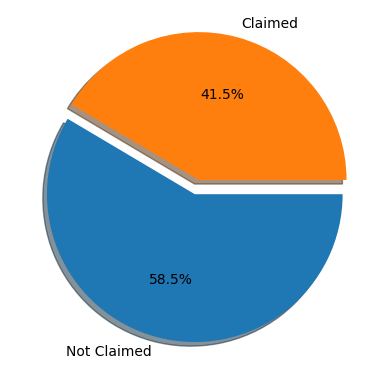

In [39]:
#Let us first analyze the distribution of the target variable

MAP={}
for e, i in enumerate(sorted(df[target].unique())):
    MAP[i]=labels[e]
#MAP={0:'Not-Survived',1:'Survived'}
df1 = df.copy()
df1[target]=df1[target].map(MAP)
explode=np.zeros(len(labels))
explode[-1]=0.1
print('\033[1mTarget Variable Distribution'.center(55))
plt.pie(df1[target].value_counts(), labels=df1[target].value_counts().index, counterclock=False, shadow=True, 
        explode=explode, autopct='%1.1f%%', radius=1, startangle=0)
plt.show()

Inference: The Target Variable seems to be slightly imbalanced! Hence we shall try to perform data augmentation.

                               Categorical Features Distribution:                               


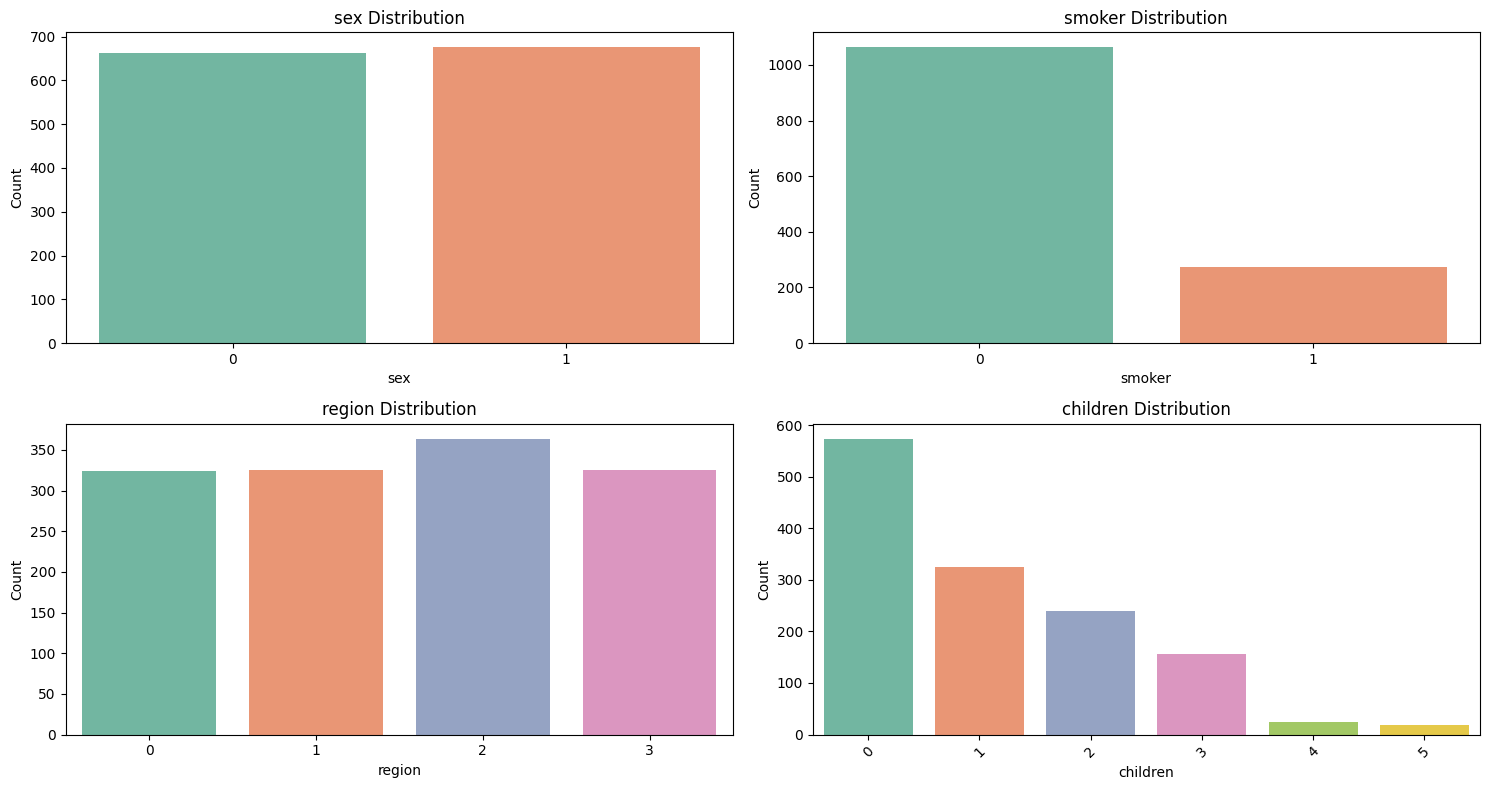

In [40]:
# Visualizing all categorical features with count plots
print('\033[1mCategorical Features Distribution:'.center(100))

n_cols = 2  # Number of columns in subplot grid
n_rows = math.ceil(len(cf) / n_cols)

plt.figure(figsize=[15, 4*n_rows])

for i in range(len(cf)):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data=df, x=cf[i], palette='Set2')
    plt.title(f'{cf[i]} Distribution')
    plt.xlabel(cf[i])
    plt.ylabel('Count')
    
    # Rotate x-axis labels if there are many unique values
    if df[cf[i]].nunique() > 5:
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Inference: Visualizing the categorical features reveal lot of information about the dataset.

                                     Features Distribution                                      


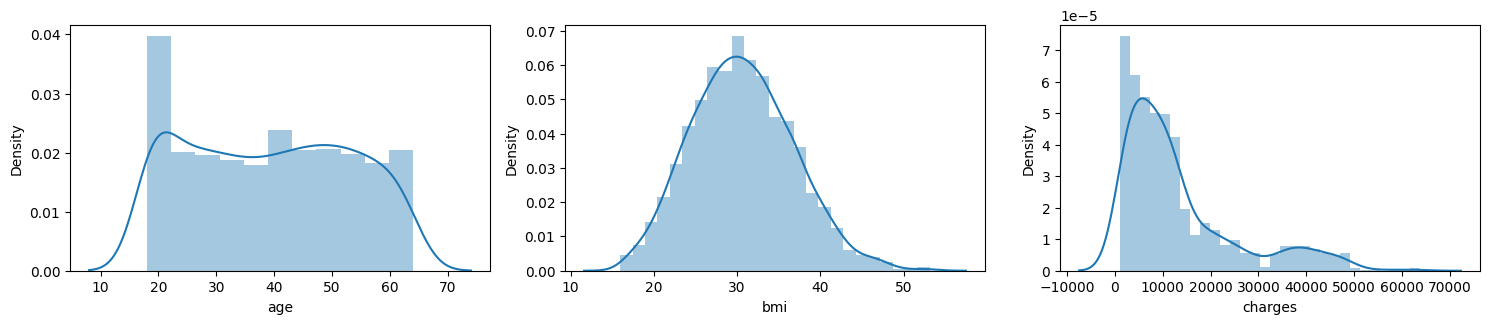

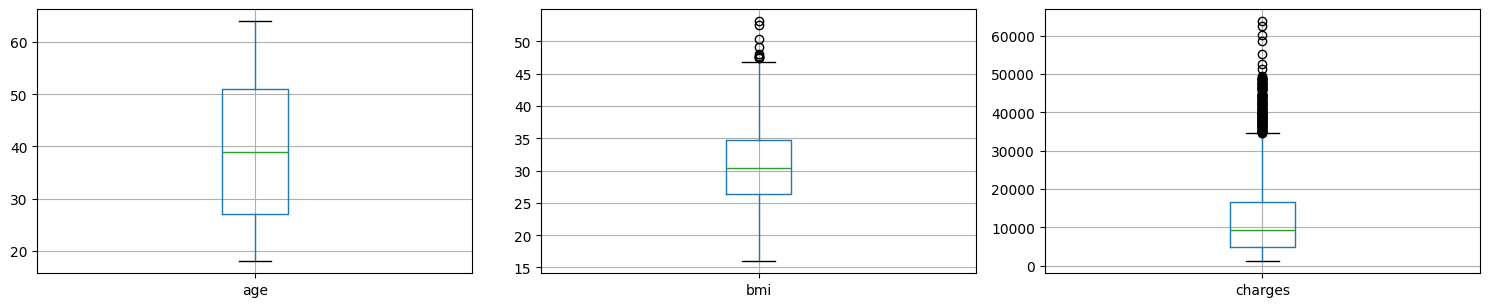

In [41]:
#Understanding the feature set

print('\033[1mFeatures Distribution'.center(100))

nf = [i for i in features if i not in cf]

plt.figure(figsize=[15,3*math.ceil(len(features)/3)])
for c in range(len(nf)):
    plt.subplot(math.ceil(len(features)/3),3,c+1)
    sns.distplot(df[nf[c]])
plt.tight_layout()
plt.show()

plt.figure(figsize=[15,3*math.ceil(len(features)/3)])
for c in range(len(nf)):
    plt.subplot(math.ceil(len(features)/3),3,c+1)
    df.boxplot(nf[c])
plt.tight_layout()
plt.show()

Inference: The data is somewhat normally distributed. And there are many outliers present in the dataset. We shall fix these outliers..

## 3. Data Preprocessing

In [42]:
#Removal of any Duplicate rows (if any)

counter = 0
r,c = original_df.shape

df1 = df.copy()
df1.drop_duplicates(inplace=True)
df1.reset_index(drop=True,inplace=True)

if df1.shape==(r,c):
    print('\n\033[1mInference:\033[0m The dataset doesn\'t have any duplicates')
else:
    print(f'\n\033[1mInference:\033[0m Number of duplicates dropped ---> {r-df1.shape[0]}')


Inference: Number of duplicates dropped ---> 1


In [43]:
#Check for empty elements

nvc = pd.DataFrame(df1.isnull().sum().sort_values(), columns=['Total Null Values'])
nvc['Percentage'] = round(nvc['Total Null Values']/df1.shape[0],3)*100
print(nvc)

                Total Null Values  Percentage
age                             0         0.0
sex                             0         0.0
bmi                             0         0.0
children                        0         0.0
smoker                          0         0.0
region                          0         0.0
charges                         0         0.0
insuranceclaim                  0         0.0


Inference: There are many outliers in the dataset. Let us try to impute the missing values

In [44]:
#Converting categorical Columns to Numeric

#df1 = df.copy()
ecc = nvc[nvc['Percentage']!=0].index.values
dcc = [i for i in df.columns if i not in ecc]

df3 = df1[dcc]
fcc = [i for i in cf if i not in ecc]

#One-Hot Binay Encoding
oh=True
dm=True
for i in fcc:
    #print(i)
    if df3[i].nunique()==2:
        if oh==True: print("\033[1m\nOne-Hot Encoding on features:\033[0m")
        print(i);oh=False
        df3[i]=pd.get_dummies(df3[i], drop_first=True, prefix=str(i))
    if (df3[i].nunique()>2 and df3[i].nunique()<17):
        if dm==True: print("\n\033[1mDummy Encoding on features:\033[0m")
        print(i);dm=False
        df3 = pd.concat([df3.drop([i], axis=1), pd.DataFrame(pd.get_dummies(df3[i], drop_first=True, prefix=str(i)))],axis=1)
        
df3.shape


One-Hot Encoding on features:
sex
smoker

Dummy Encoding on features:
region
children


(1337, 14)

In [45]:
#Removal of outlier:

df4 = df3.copy()

for i in [i for i in df4.columns]:
    if df4[i].nunique()>=12:
        Q1 = df4[i].quantile(0.25)
        Q3 = df4[i].quantile(0.75)
        IQR = Q3 - Q1
        df4 = df4[df4[i] <= (Q3+(1.5*IQR))]
        df4 = df4[df4[i] >= (Q1-(1.5*IQR))]
df4 = df4.reset_index(drop=True)
display(df4.head())
print('\n\033[1mInference:\033[0m Before removal of outliers, The dataset had {} samples.'.format(df1.shape[0]))
print('\033[1mInference:\033[0m After removal of outliers, The dataset now has {} samples.'.format(df4.shape[0]))

,age,sex,bmi,smoker,charges,insuranceclaim,region_1,region_2,region_3,children_1,children_2,children_3,children_4,children_5
0,19,False,27.900,True,16884.92400,1,False,False,True,False,False,False,False,False
1,18,True,33.770,False,1725.55230,1,False,True,False,True,False,False,False,False
2,28,True,33.000,False,4449.46200,0,False,True,False,False,False,True,False,False
3,33,True,22.705,False,21984.47061,0,True,False,False,False,False,False,False,False
4,32,True,28.880,False,3866.85520,1,True,False,False,False,False,False,False,False



Inference: Before removal of outliers, The dataset had 1337 samples.
Inference: After removal of outliers, The dataset now has 1190 samples.


In [46]:
#Fixing the imbalance using SMOTE Technique

df5 = df4.copy()

print('Original class distribution:')
print(df5[target].value_counts())

xf = df5.columns
X = df5.drop([target],axis=1)
Y = df5[target]

smote = SMOTE()
X, Y = smote.fit_resample(X, Y)

df5 = pd.DataFrame(X, columns=xf)
df5[target] = Y

print('\nClass distribution after applying SMOTE Technique:',)
print(Y.value_counts())

Original class distribution:
insuranceclaim
1    638
0    552
Name: count, dtype: int64

Class distribution after applying SMOTE Technique:
insuranceclaim
1    638
0    638
Name: count, dtype: int64


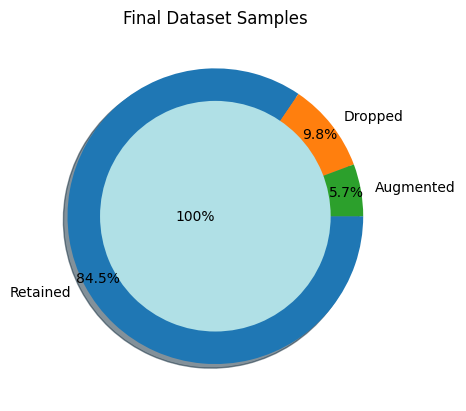


Inference:The final dataset after cleanup has 1276 samples & 14 columns.


In [47]:
#Final Dataset size after performing Preprocessing

df = df5.copy()
plt.title('Final Dataset Samples')
plt.pie([df.shape[0], original_df.shape[0]-df4.shape[0], df5.shape[0]-df4.shape[0]], radius = 1, shadow=True,
        labels=['Retained','Dropped','Augmented'], counterclock=False, autopct='%1.1f%%', pctdistance=0.9, explode=[0,0,0])
plt.pie([df.shape[0]], labels=['100%'], labeldistance=-0, radius=0.78, shadow=True, colors=['powderblue'])
plt.show()

print('\n\033[1mInference:\033[0mThe final dataset after cleanup has {} samples & {} columns.'.format(df.shape[0], df.shape[1]))    

## 4. Data Manipulation

In [48]:
#Splitting the data intro training & testing sets

df = df5.copy()

X = df.drop([target],axis=1)
Y = df[target]
Train_X, Test_X, Train_Y, Test_Y = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=0)

print('Original set  ---> ',X.shape,Y.shape,'\nTraining set  ---> ',Train_X.shape,Train_Y.shape,'\nTesting set   ---> ', Test_X.shape,'', Test_Y.shape)

Original set  --->  (1276, 13) (1276,) 
Training set  --->  (1020, 13) (1020,) 
Testing set   --->  (256, 13)  (256,)


In [49]:
#Feature Scaling (Standardization)

std = StandardScaler()

print('\033[1mStandardardization on Training set'.center(100))
Train_X_std = std.fit_transform(Train_X)
Train_X_std = pd.DataFrame(Train_X_std, columns=X.columns)
display(Train_X_std.describe())

print('\n','\033[1mStandardardization on Testing set'.center(100))
Test_X_std = std.transform(Test_X)
Test_X_std = pd.DataFrame(Test_X_std, columns=X.columns)
display(Test_X_std.describe())

                               Standardardization on Training set                               


,age,sex,bmi,smoker,charges,region_1,region_2,region_3,children_1,children_2,children_3,children_4,children_5
count,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03
mean,1.149407e-16,2.786442e-17,-8.185174e-17,-8.011021e-17,3.134747e-17,-1.915679e-17,6.791953e-17,4.179663e-17,-6.530724e-17,8.359326e-17,-5.398732e-17,6.966105e-18,3.483053e-17
std,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00
min,-1.493261e+00,-1.013821e+00,-2.378873e+00,-3.582158e-01,-1.214212e+00,-6.166389e-01,-5.803691e-01,-5.788597e-01,-5.894269e-01,-4.892527e-01,-3.771170e-01,-1.710654e-01,-1.340301e-01
25%,-9.178179e-01,-1.013821e+00,-7.204095e-01,-3.582158e-01,-7.587054e-01,-6.166389e-01,-5.803691e-01,-5.788597e-01,-5.894269e-01,-4.892527e-01,-3.771170e-01,-1.710654e-01,-1.340301e-01
50%,1.727740e-02,9.863674e-01,-5.777568e-02,-3.582158e-01,-2.213568e-01,-6.166389e-01,-5.803691e-01,-5.788597e-01,-5.894269e-01,-4.892527e-01,-3.771170e-01,-1.710654e-01,-1.340301e-01
75%,8.804423e-01,9.863674e-01,6.268833e-01,-3.582158e-01,4.156789e-01,1.621695e+00,1.723041e+00,1.727534e+00,1.696563e+00,-4.892527e-01,-3.771170e-01,-1.710654e-01,-1.340301e-01
max,1.815538e+00,9.863674e-01,2.944523e+00,2.791613e+00,3.379729e+00,1.621695e+00,1.723041e+00,1.727534e+00,1.696563e+00,2.043934e+00,2.651697e+00,5.845718e+00,7.461010e+00



                                Standardardization on Testing set                                


,age,sex,bmi,smoker,charges,region_1,region_2,region_3,children_1,children_2,children_3,children_4,children_5
count,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000
mean,0.029921,-0.076233,0.082484,-0.013703,-0.048272,-0.057056,0.058467,0.087832,0.035649,-0.053861,0.096135,-0.100556,-0.045026
std,1.010034,1.000094,1.018160,0.985016,0.924199,0.971125,1.033228,1.047599,1.020915,0.957572,1.101893,0.648777,0.818957
min,-1.493261,-1.013821,-1.853277,-0.358216,-1.211503,-0.616639,-0.580369,-0.578860,-0.589427,-0.489253,-0.377117,-0.171065,-0.134030
25%,-0.845888,-1.013821,-0.654259,-0.358216,-0.780358,-0.616639,-0.580369,-0.578860,-0.589427,-0.489253,-0.377117,-0.171065,-0.134030
50%,0.017277,-1.013821,0.011157,-0.358216,-0.225849,-0.616639,-0.580369,-0.578860,-0.589427,-0.489253,-0.377117,-0.171065,-0.134030
75%,0.880442,0.986367,0.743154,-0.358216,0.423303,-0.057056,1.723041,1.727534,1.696563,-0.489253,-0.377117,-0.171065,-0.134030
max,1.815538,0.986367,2.906487,2.791613,3.264651,1.621695,1.723041,1.727534,1.696563,2.043934,2.651697,5.845718,7.461010


## 5. Feature Selection/Extraction

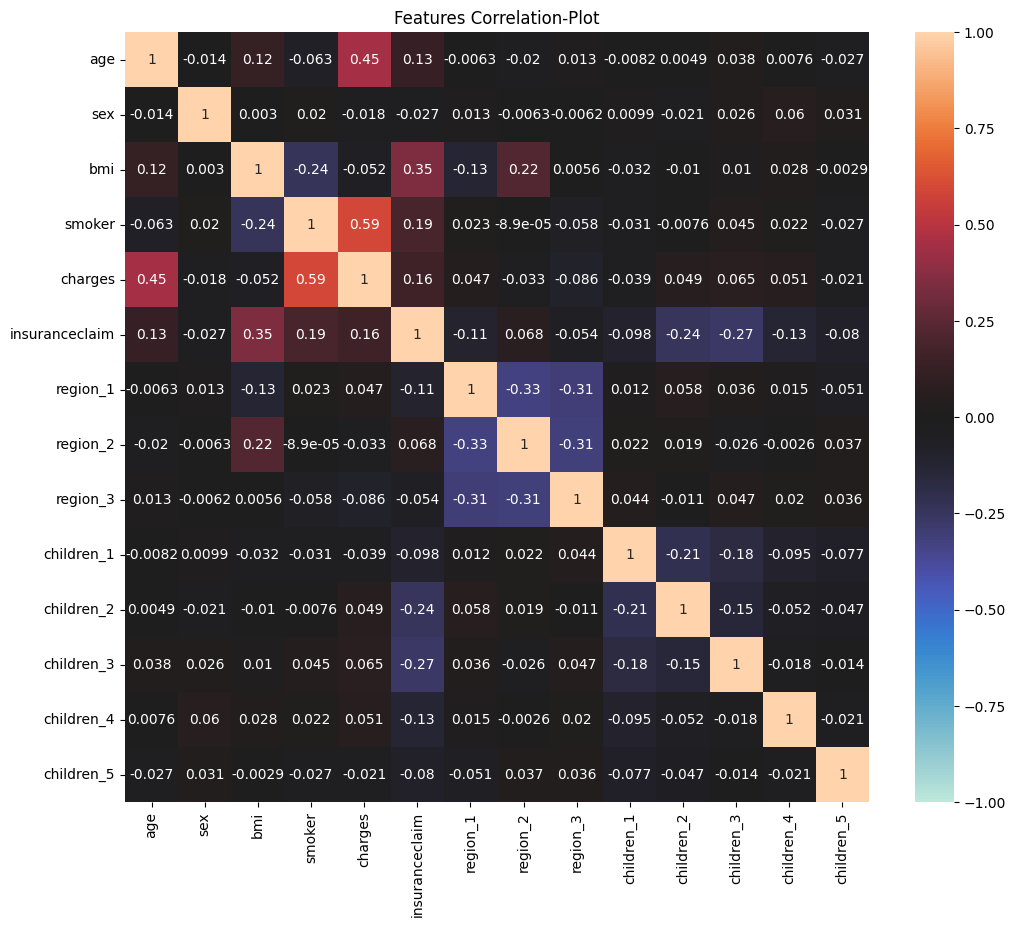

In [50]:
#Checking the correlation

features = df.columns
plt.figure(figsize=[12,10])
plt.title('Features Correlation-Plot')
sns.heatmap(df[features].corr(), vmin=-1, vmax=1, center=0, annot=True) #, 
plt.show()

Inference:  Correlation plt between the variables convey lot of information about the realationship betweem them. There seems to be strong multicollinearity in the dataset.

Let us check with different techniques if we can improve the model's performance by performing Feature Selection/Extraction steps to take care of these multi-collinearity...

Strategy:  We can fix these multicollinearity with two techniques:

Manual Method - Variance Inflation Factor (VIF)
Automatic Method - Recursive Feature Elimination (RFE)
Decomposition Method - Principle Component Analysis (PCA)

### 5a. Manual Method - VIF

100%|██████████| 12/12 [00:04<00:00,  2.83it/s]


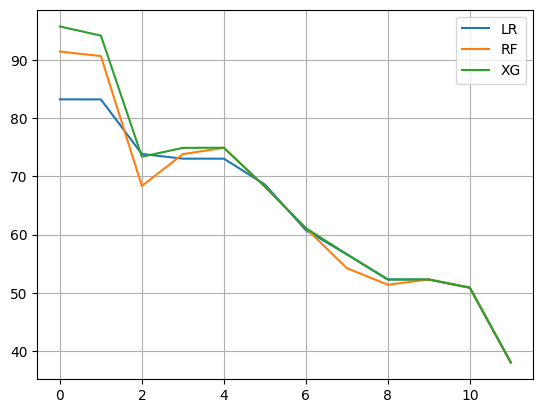

In [51]:
# Calculate the VIFs to remove multicollinearity

DROP=[]; scores1=[]; scores2=[]; scores3=[]
#scores.append(f1_score(Test_Y,LogisticRegression().fit(Train_X_std, Train_Y).predict(Test_X_std)))
scores1.append(f1_score(Test_Y,LogisticRegression().fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
scores2.append(f1_score(Test_Y,RandomForestClassifier().fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
scores3.append(f1_score(Test_Y,XGBClassifier(eval_metric='logloss').fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
        
for i in tqdm(range(len(X.columns.values)-1)):
    vif = pd.DataFrame()
    Xs = X.drop(DROP,axis=1)

    # ensure all columns are numeric (coerce non-numeric to NaN then fill)
    Xs = Xs.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)

    # compute VIFs safely — catch errors and mark as inf
    vif['Features'] = Xs.columns
    vif_vals = []
    for j in range(Xs.shape[1]):
        try:
            v = variance_inflation_factor(Xs.values, j)
            # protect against non-finite results
            if not np.isfinite(v):
                v = np.inf
        except Exception:
            v = np.inf
        vif_vals.append(v)

    vif['VIF'] = [round(x, 2) if np.isfinite(x) else np.inf for x in vif_vals]
    vif = vif.sort_values(by = "VIF", ascending = False)
    vif.reset_index(drop=True, inplace=True)
    DROP.append(vif.Features[0])
    if vif.VIF[0]>1:
        scores1.append(f1_score(Test_Y,LogisticRegression().fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
        scores2.append(f1_score(Test_Y,RandomForestClassifier().fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
        scores3.append(f1_score(Test_Y,XGBClassifier(eval_metric='logloss').fit(Train_X_std.drop(DROP,axis=1), Train_Y).predict(Test_X_std.drop(DROP,axis=1)),average='weighted')*100)
    #print(scores)
    
plt.plot(scores1, label='LR')
plt.plot(scores2, label='RF')
plt.plot(scores3, label='XG')
#plt.ylim([0.7,0.85])
plt.legend()
plt.grid()
plt.show()

### 5b. Automatic Method - RFE

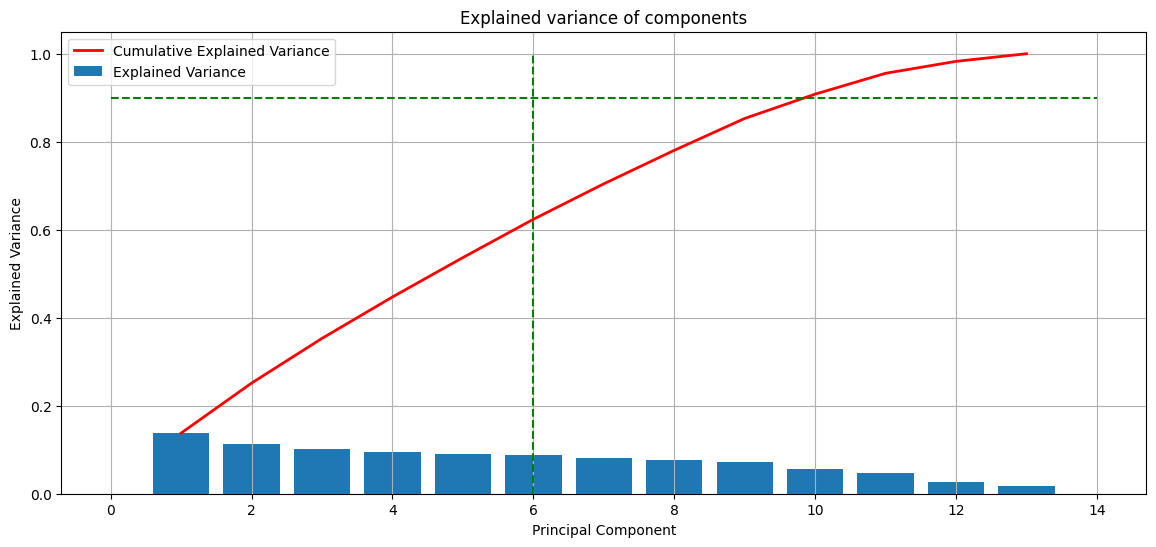

In [52]:
from sklearn.decomposition import PCA

pca = PCA().fit(Train_X_std)

fig, ax = plt.subplots(figsize=(14,6))
x_values = range(1, pca.n_components_+1)
ax.bar(x_values, pca.explained_variance_ratio_, lw=2, label='Explained Variance')
ax.plot(x_values, np.cumsum(pca.explained_variance_ratio_), lw=2, label='Cumulative Explained Variance', color='red')
plt.plot([0,pca.n_components_+1],[0.90,0.90],'g--')
plt.plot([6,6],[0,1], 'g--')
ax.set_title('Explained variance of components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance')
plt.grid()
plt.legend()
plt.show()

Inference: We shall avoid performing dimensionality reduction for the current problem.

100%|██████████| 13/13 [00:06<00:00,  2.00it/s]


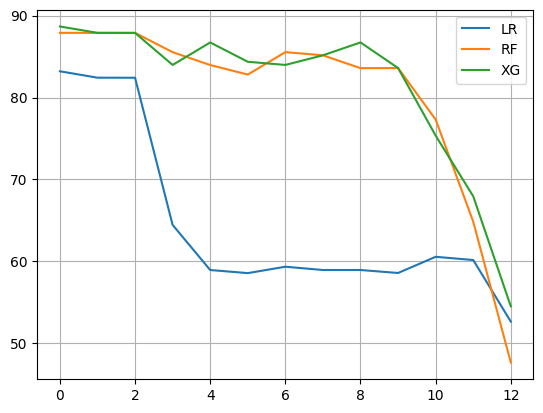

In [53]:
from sklearn.decomposition import PCA

scores1=[]; scores2=[]; scores3=[]
for i in tqdm(range(len(X.columns.values))):
    n_comp = max(1, Train_X_std.shape[1]-i)
    pca = PCA(n_components=n_comp)
    Train_X_std_pca = pca.fit_transform(Train_X_std)
    Train_X_std_pca = pd.DataFrame(Train_X_std_pca)

    Test_X_std_pca = pca.transform(Test_X_std)
    Test_X_std_pca = pd.DataFrame(Test_X_std_pca)

    scores1.append(f1_score(Test_Y, LogisticRegression().fit(Train_X_std_pca, Train_Y).predict(Test_X_std_pca), average='weighted')*100)
    scores2.append(f1_score(Test_Y, RandomForestClassifier().fit(Train_X_std_pca, Train_Y).predict(Test_X_std_pca), average='weighted')*100)
    scores3.append(f1_score(Test_Y, XGBClassifier(eval_metric='logloss').fit(Train_X_std_pca, Train_Y).predict(Test_X_std_pca), average='weighted')*100)

plt.plot(scores1, label='LR')
plt.plot(scores2, label='RF')
plt.plot(scores3, label='XG')
#plt.ylim([0.80,0.84])
plt.legend()
plt.grid()
plt.show()


Inference: In VIF, RFE & PCA Techniques, we did notice any better scores upon dropping some multicollinear features. But in order to avoid the curse of dimensionality, we can capture top 90% of the data Variance explained by top n PCA components.

In [54]:
#### Finalising the shortlisted features

# Use LogisticRegression() instance as estimator for RFE
rfe = RFE(LogisticRegression(), n_features_to_select=len(Train_X_std.columns))   
rfe = rfe.fit(Train_X_std, Train_Y)

# Evaluate models on the selected features
sel_cols = Train_X_std.columns[rfe.support_]
print(f1_score(Test_Y, LogisticRegression().fit(Train_X_std[sel_cols], Train_Y).predict(Test_X_std[sel_cols]), average='weighted')*100)
print(f1_score(Test_Y, RandomForestClassifier().fit(Train_X_std[sel_cols], Train_Y).predict(Test_X_std[sel_cols]), average='weighted')*100)
print(f1_score(Test_Y, XGBClassifier(eval_metric='logloss').fit(Train_X_std[sel_cols], Train_Y).predict(Test_X_std[sel_cols]), average='weighted')*100)
    
# Optionally keep only selected columns
# Train_X_std = Train_X_std[Train_X_std.columns[rfe.support_]]
# Test_X_std = Test_X_std[Test_X_std.columns[rfe.support_]]

print(Train_X_std.shape)
print(Test_X_std.shape)

83.20081544572608
92.18893059879143
95.70410885194853
(1020, 13)
(256, 13)


## 6. Predictive Modeling

In [55]:

Evaluation_Results = pd.DataFrame(np.zeros((8,5)), columns=['Accuracy', 'Precision','Recall','F1-score','AUC-ROC score'])
Evaluation_Results.index=['Logistic Regression (LR)','Decision Tree Classifier (DT)','Random Forest Classifier (RF)','Naïve Bayes Classifier (NB)',
                         'Support Vector Machine (SVM)','K Nearest Neighbours (KNN)', 'Gradient Boosting (GB)','Extreme Gradient Boosting (XGB)']
Evaluation_Results

,Accuracy,Precision,Recall,F1-score,AUC-ROC score
Logistic Regression (LR),0.0,0.0,0.0,0.0,0.0
Decision Tree Classifier (DT),0.0,0.0,0.0,0.0,0.0
Random Forest Classifier (RF),0.0,0.0,0.0,0.0,0.0
Naïve Bayes Classifier (NB),0.0,0.0,0.0,0.0,0.0
Support Vector Machine (SVM),0.0,0.0,0.0,0.0,0.0
K Nearest Neighbours (KNN),0.0,0.0,0.0,0.0,0.0
Gradient Boosting (GB),0.0,0.0,0.0,0.0,0.0
Extreme Gradient Boosting (XGB),0.0,0.0,0.0,0.0,0.0


In [72]:
#Let us define functions to summarise the Prediction's scores .

#Classification Summary Function
# def Classification_Summary(pred,pred_prob,i):
#     Evaluation_Results.iloc[i]['Accuracy']=round(accuracy_score(Test_Y, pred),3)*100   
#     Evaluation_Results.iloc[i]['Precision']=round(precision_score(Test_Y, pred, average='weighted'),3)*100 #
#     Evaluation_Results.iloc[i]['Recall']=round(recall_score(Test_Y, pred, average='weighted'),3)*100 #
#     Evaluation_Results.iloc[i]['F1-score']=round(f1_score(Test_Y, pred, average='weighted'),3)*100 #
#     Evaluation_Results.iloc[i]['AUC-ROC score']=round(roc_auc_score(Test_Y, pred_prob[:,1], multi_class='ovr'),3)*100 #[:, 1]
#     print('{}{}\033[1m Evaluating {} \033[0m{}{}\n'.format('<'*3,'-'*35,Evaluation_Results.index[i], '-'*35,'>'*3))
#     print('Accuracy = {}%'.format(round(accuracy_score(Test_Y, pred),3)*100))
#     print('F1 Score = {}%'.format(round(f1_score(Test_Y, pred, average='weighted'),3)*100)) #
#     print('\n \033[1mConfusiton Matrix:\033[0m\n',confusion_matrix(Test_Y, pred))
#     print('\n\033[1mClassification Report:\033[0m\n',classification_report(Test_Y, pred))
    
#     auc_roc(Test_Y, pred_prob, curves=['each_class'])
#     plt.show()



def Classification_Summary(pred, pred_prob, i):
    Evaluation_Results.iloc[i]['Accuracy'] = round(accuracy_score(Test_Y, pred), 3) * 100
    Evaluation_Results.iloc[i]['Precision'] = round(
        precision_score(Test_Y, pred, average='weighted'), 3) * 100
    Evaluation_Results.iloc[i]['Recall'] = round(
        recall_score(Test_Y, pred, average='weighted'), 3) * 100
    Evaluation_Results.iloc[i]['F1-score'] = round(
        f1_score(Test_Y, pred, average='weighted'), 3) * 100

    # ALWAYS use probability of positive class (class = 1)
    Evaluation_Results.iloc[i]['AUC-ROC score'] = round(
        roc_auc_score(Test_Y, pred_prob[:, 1]), 3) * 100

    print(f"\n<<<{'-'*35} Evaluating {Evaluation_Results.index[i]} {'-'*35}>>>")
    print(f"Accuracy = {accuracy_score(Test_Y, pred)*100:.2f}%")
    print(f"F1 Score = {f1_score(Test_Y, pred, average='weighted')*100:.2f}%")

    print("\nConfusion Matrix:\n", confusion_matrix(Test_Y, pred))
    print("\nClassification Report:\n", classification_report(Test_Y, pred))

    auc_roc(Test_Y, pred_prob)


# Plot per-class ROC curves helper (fix for missing auc_roc)
# def auc_roc(y_true, y_score, curves=['each_class']):
    # y_score expected shape (n_samples, n_classes) - probability estimates
    # from sklearn.preprocessing import label_binarize
    # y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
    # n_classes = y_true_bin.shape[1] if y_true_bin.ndim>1 else 1
    # plt.figure(figsize=(8,6))
    # if 'each_class' in curves:
    #     for i in range(n_classes):
    #         fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    #         auc = roc_auc_score(y_true_bin[:, i], y_score[:, i])
    #         plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc:.2f})')
    # if 'macro' in curves:
    #     aucs = [roc_auc_score(y_true_bin[:, i], y_score[:, i]) for i in range(n_classes)]
    #     plt.title(f'Macro AUC = {np.mean(aucs):.2f}')
    # plt.plot([0,1],[0,1],'k--')
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.legend()
    # plt.show()


#Visualising Function
# def AUC_ROC_plot(Test_Y, pred):    
#     ref = [0 for _ in range(len(Test_Y))]
#     ref_auc = roc_auc_score(Test_Y, ref)
#     lr_auc = roc_auc_score(Test_Y, pred)

#     ns_fpr, ns_tpr, _ = roc_curve(Test_Y, ref)
#     lr_fpr, lr_tpr, _ = roc_curve(Test_Y, pred)

#     plt.plot(ns_fpr, ns_tpr, linestyle='--')
#     plt.plot(lr_fpr, lr_tpr, marker='.', label='AUC = {}'.format(round(roc_auc_score(Test_Y, pred)*100,2))) 
#     plt.xlabel('False Positive Rate')
#     plt.ylabel('True Positive Rate')
#     plt.legend()
#     plt.show()


def auc_roc(y_true, y_score):
    """
    Correct ROC plotting using probabilities
    """
    from sklearn.metrics import roc_curve, auc

    # Positive class probability ONLY
    fpr, tpr, _ = roc_curve(y_true, y_score[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()



## 1. Logistic Regression:


<<<----------------------------------- Evaluating Logistic Regression (LR) ----------------------------------->>>
Accuracy = 83.20%
F1 Score = 83.20%

Confusion Matrix:
 [[102  22]
 [ 21 111]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.83       124
           1       0.83      0.84      0.84       132

    accuracy                           0.83       256
   macro avg       0.83      0.83      0.83       256
weighted avg       0.83      0.83      0.83       256



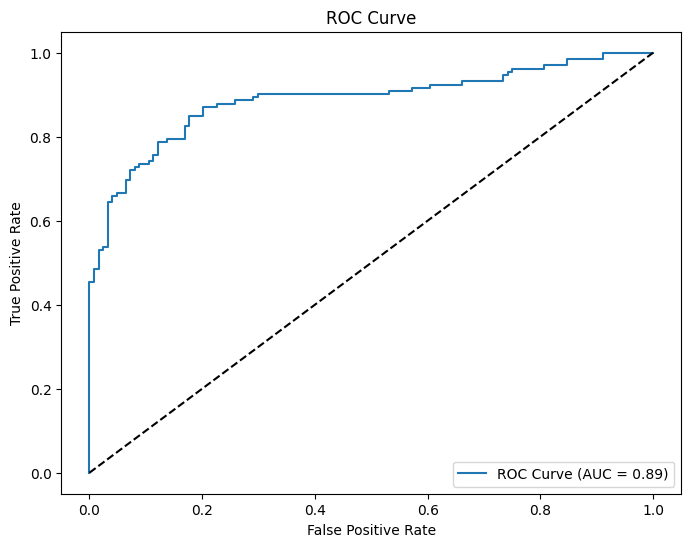


Interpreting the Output of Logistic Regression:

intercept  -0.06622123735201811
classes [0 1]


,coeff
age,0.433122
sex,-0.137535
bmi,1.657203
smoker,1.268503
charges,-0.029119
region_1,-0.236330
region_2,-0.169661
region_3,-0.189244
children_1,-0.935628
children_2,-1.415320


In [73]:
# Building Logistic Regression Classifier

LR_model = LogisticRegression()

space = dict()
space['solver'] = ['newton-cg', 'lbfgs', 'liblinear']
space['penalty'] = ['l2'] #'none', 'l1', 'l2', 'elasticnet'
space['C'] = loguniform(1e-5, 100)

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

RCV = RandomizedSearchCV(LR_model, space, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5, random_state=1)

LR = RCV.fit(Train_X_std, Train_Y).best_estimator_
pred = LR.predict(Test_X_std)
pred_prob = LR.predict_proba(Test_X_std)
Classification_Summary(pred,pred_prob,0)

print('\n\033[1mInterpreting the Output of Logistic Regression:\n\033[0m')

print('intercept ', LR.intercept_[0])
print('classes', LR.classes_)
display(pd.DataFrame({'coeff': LR.coef_[0]}, index=Train_X_std.columns))

## 2. Decisoin Tree Classfier:


<<<----------------------------------- Evaluating Decision Tree Classifier (DT) ----------------------------------->>>
Accuracy = 86.33%
F1 Score = 86.31%

Confusion Matrix:
 [[113  11]
 [ 24 108]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.87       124
           1       0.91      0.82      0.86       132

    accuracy                           0.86       256
   macro avg       0.87      0.86      0.86       256
weighted avg       0.87      0.86      0.86       256



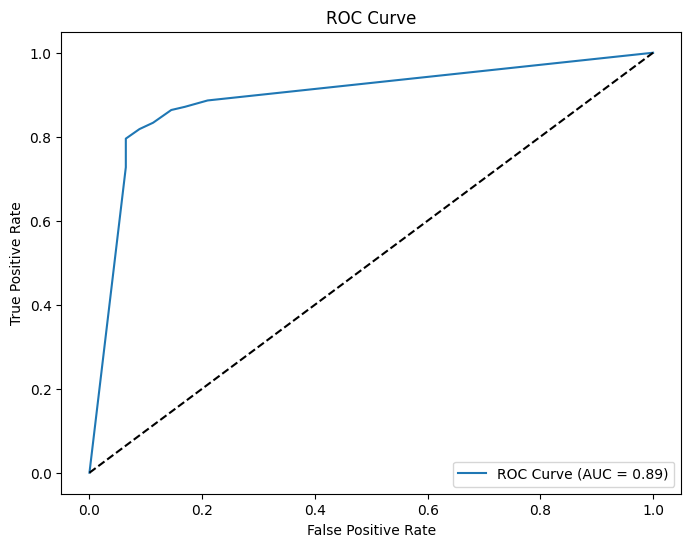


Interpreting the output of Decision Tree:



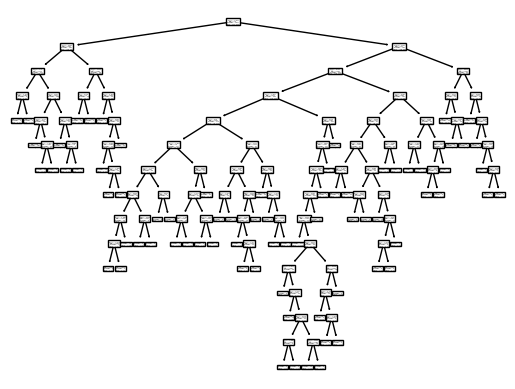

In [74]:
#Building Decision Tree Classifier

DT_model = DecisionTreeClassifier()

param_dist = {"max_depth": [3, None],
              "max_features": randint(1, len(features)-1),
              "min_samples_leaf": randint(1, len(features)-1),
              "criterion": ["gini", "entropy"]}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

RCV = RandomizedSearchCV(DT_model, param_dist, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5, random_state=1)

DT = RCV.fit(Train_X_std, Train_Y).best_estimator_
pred = DT.predict(Test_X_std)
pred_prob = DT.predict_proba(Test_X_std)
Classification_Summary(pred,pred_prob,1)

print('\n\033[1mInterpreting the output of Decision Tree:\n\033[0m')
tree.plot_tree(DT)
plt.show()

## 3. Random Forest Classfier:


<<<----------------------------------- Evaluating Random Forest Classifier (RF) ----------------------------------->>>
Accuracy = 92.58%
F1 Score = 92.58%

Confusion Matrix:
 [[119   5]
 [ 14 118]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.93       124
           1       0.96      0.89      0.93       132

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256



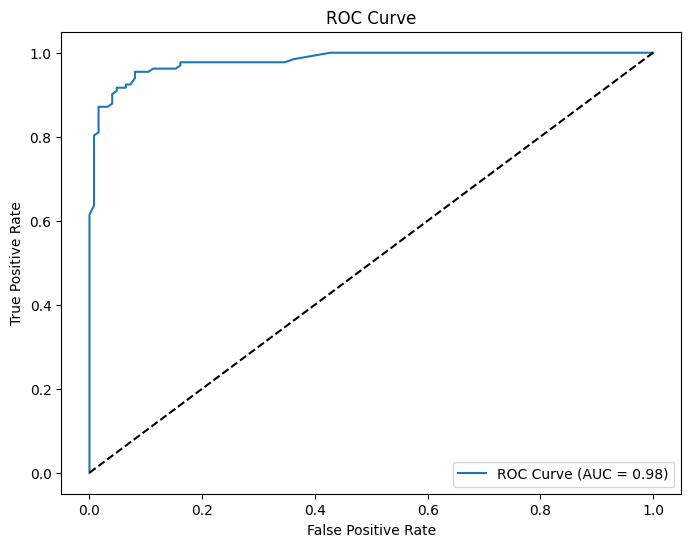


Interpreting the output of Random Forest:



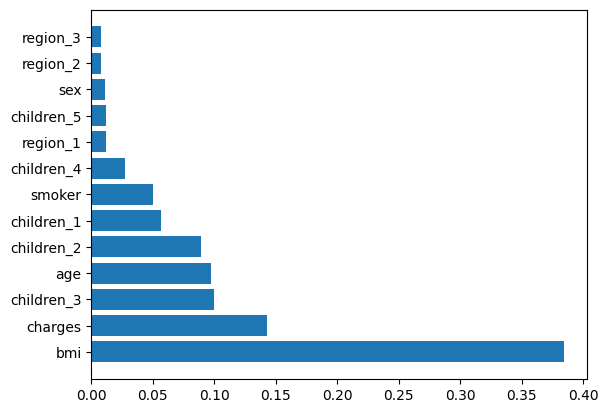

In [75]:
# Building Random-Forest Classifier

RF_model = RandomForestClassifier()

param_dist={'bootstrap': [True, False],
            'max_depth': [10, 20, 50, 100, None],
            'max_features': ['auto', 'sqrt'],
            'min_samples_leaf': [1, 2, 4],
            'min_samples_split': [2, 5, 10],
            'n_estimators': [50, 100]}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

RCV = RandomizedSearchCV(RF_model, param_dist, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5, random_state=1)

RF = RCV.fit(Train_X_std, Train_Y).best_estimator_
pred = RF.predict(Test_X_std)
pred_prob = RF.predict_proba(Test_X_std)
Classification_Summary(pred,pred_prob,2)

print('\n\033[1mInterpreting the output of Random Forest:\n\033[0m')
rfi=pd.Series(RF.feature_importances_, index=Train_X_std.columns).sort_values(ascending=False)
plt.barh(rfi.index,rfi.values)
plt.show()


## 4. Naive Bayes Classfier:


<<<----------------------------------- Evaluating Naïve Bayes Classifier (NB) ----------------------------------->>>
Accuracy = 77.34%
F1 Score = 77.33%

Confusion Matrix:
 [[ 93  31]
 [ 27 105]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.75      0.76       124
           1       0.77      0.80      0.78       132

    accuracy                           0.77       256
   macro avg       0.77      0.77      0.77       256
weighted avg       0.77      0.77      0.77       256



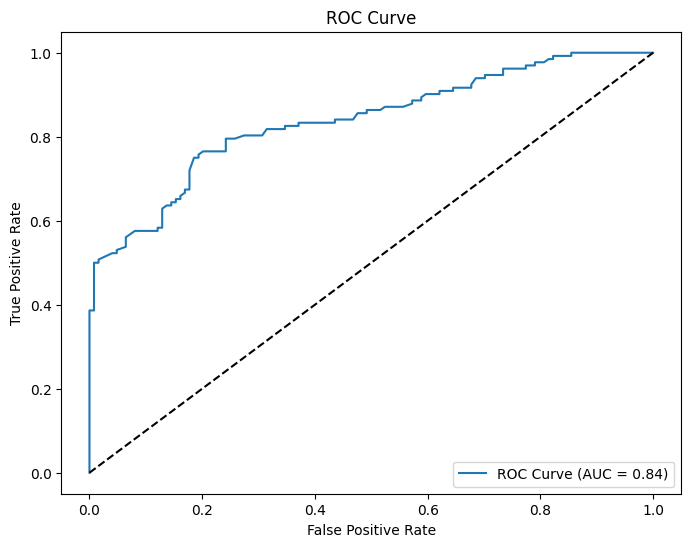

In [76]:
# Building Naive Bayes Classifier

NB_model = BernoulliNB()

params = {'alpha': [0.01, 0.1, 0.5, 1.0, 10.0]}
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

RCV = RandomizedSearchCV(NB_model, params, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5, random_state=1)

NB = RCV.fit(Train_X_std, Train_Y).best_estimator_
pred = NB.predict(Test_X_std)
pred_prob = NB.predict_proba(Test_X_std)
Classification_Summary(pred,pred_prob,3)

## 5. Support Vector Machine Classfier:


<<<----------------------------------- Evaluating Support Vector Machine (SVM) ----------------------------------->>>
Accuracy = 86.72%
F1 Score = 86.72%

Confusion Matrix:
 [[110  14]
 [ 20 112]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       124
           1       0.89      0.85      0.87       132

    accuracy                           0.87       256
   macro avg       0.87      0.87      0.87       256
weighted avg       0.87      0.87      0.87       256



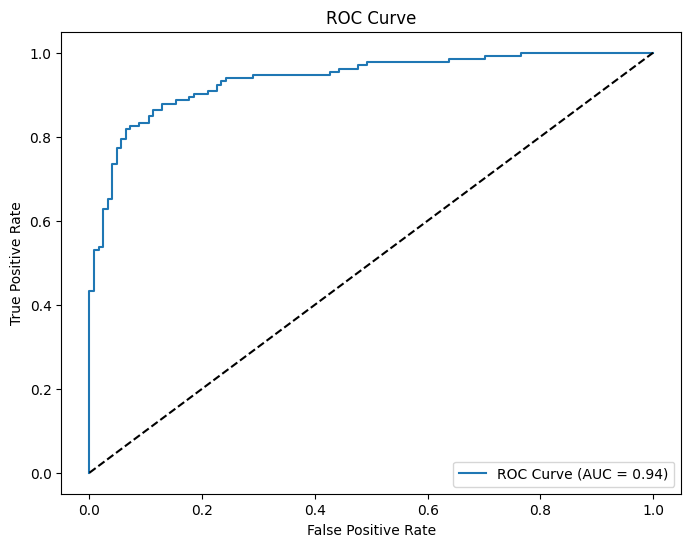

In [77]:
# Building Support Vector Machine Classifier

SVM_model = SVC(probability=True).fit(Train_X_std, Train_Y)

svm_param = {"C": [.01, .1, 1, 5, 10, 100],             
             "gamma": [.01, .1, 1, 5, 10, 100],
             "kernel": ["rbf"],
             "random_state": [1]}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

RCV = RandomizedSearchCV(SVM_model, svm_param, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5, random_state=1)

SVM = RCV.fit(Train_X_std, Train_Y).best_estimator_
pred = SVM.predict(Test_X_std)
pred_prob = SVM.predict_proba(Test_X_std)
Classification_Summary(pred,pred_prob,4)

## 6. K-Nearest Neighbours Classfier


<<<----------------------------------- Evaluating K Nearest Neighbours (KNN) ----------------------------------->>>
Accuracy = 85.94%
F1 Score = 85.94%

Confusion Matrix:
 [[107  17]
 [ 19 113]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86       124
           1       0.87      0.86      0.86       132

    accuracy                           0.86       256
   macro avg       0.86      0.86      0.86       256
weighted avg       0.86      0.86      0.86       256



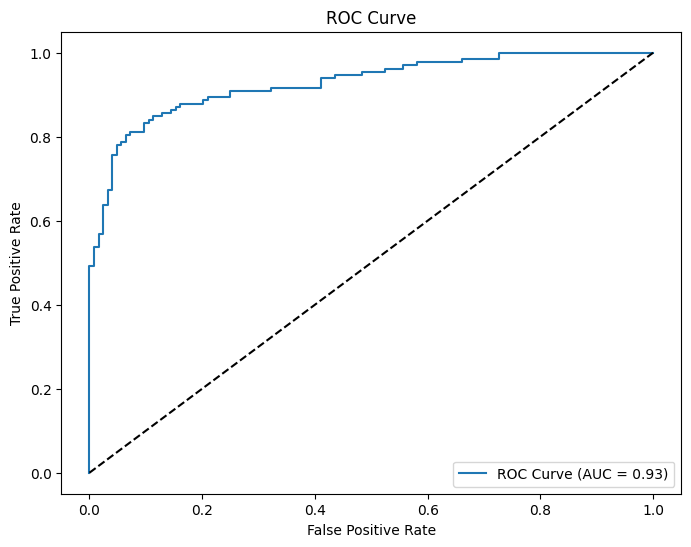

In [80]:
# Building K-Neareset Neighbours Classifier

KNN_model = KNeighborsClassifier()

knn_param = {"n_neighbors": [i for i in range(1,30,5)],
             "weights": ["uniform", "distance"],
             "algorithm": ["ball_tree", "kd_tree", "brute"],
             "leaf_size": [1, 10, 30],
             "p": [1,2]}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

RCV = RandomizedSearchCV(KNN_model, knn_param, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5, random_state=1)

KNN = RCV.fit(Train_X_std, Train_Y).best_estimator_
pred = KNN.predict(Test_X_std)
pred_prob = KNN.predict_proba(Test_X_std)
Classification_Summary(pred,pred_prob,5)


## 7. Gradient Boosting Classfier:


<<<----------------------------------- Evaluating Gradient Boosting (GB) ----------------------------------->>>
Accuracy = 93.75%
F1 Score = 93.75%

Confusion Matrix:
 [[117   7]
 [  9 123]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94       124
           1       0.95      0.93      0.94       132

    accuracy                           0.94       256
   macro avg       0.94      0.94      0.94       256
weighted avg       0.94      0.94      0.94       256



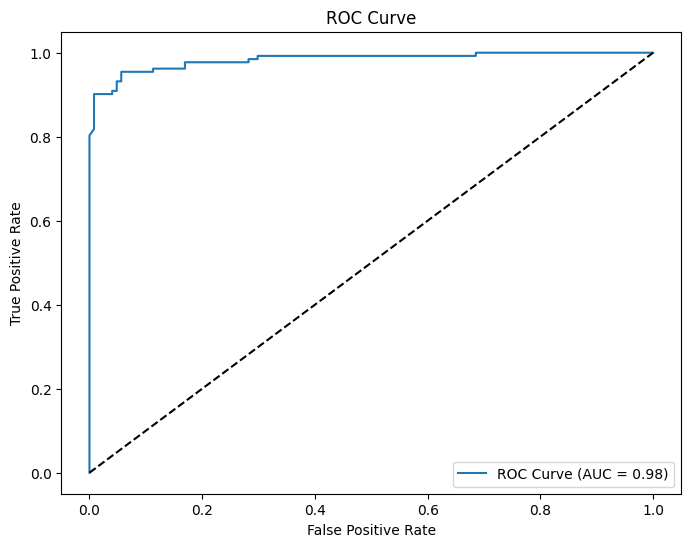

In [83]:
# Building Gradient Boosting Classifier

GB_model = GradientBoostingClassifier().fit(Train_X_std, Train_Y)
param_dist = {
    "n_estimators":[5,20,100,500],
    "max_depth":[1,3,5,7,9],
    "learning_rate":[0.01,0.1,1,10,100]
}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

#RCV = RandomizedSearchCV(GB_model, param_dist, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5, random_state=1)

GB = GB_model.fit(Train_X_std, Train_Y)#.best_estimator_
pred = GB.predict(Test_X_std)
pred_prob = GB.predict_proba(Test_X_std)
Classification_Summary(pred,pred_prob,6)

## 8. Extreme Gradient Boosting Classfier:


<<<----------------------------------- Evaluating Extreme Gradient Boosting (XGB) ----------------------------------->>>
Accuracy = 95.70%
F1 Score = 95.70%

Confusion Matrix:
 [[120   4]
 [  7 125]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       124
           1       0.97      0.95      0.96       132

    accuracy                           0.96       256
   macro avg       0.96      0.96      0.96       256
weighted avg       0.96      0.96      0.96       256



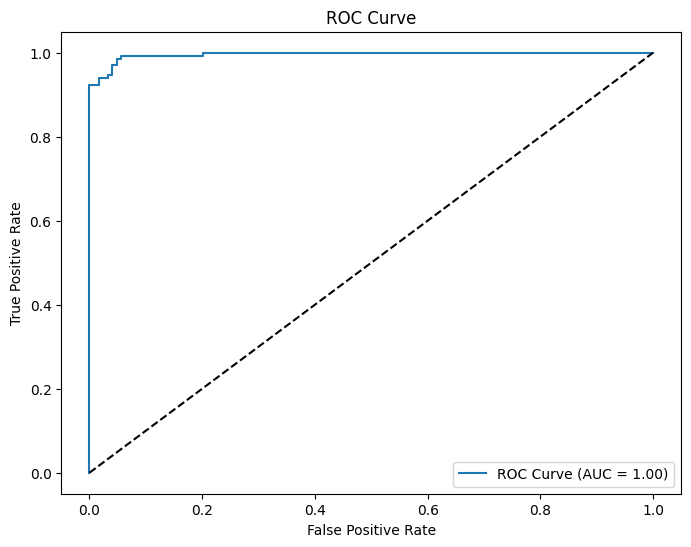

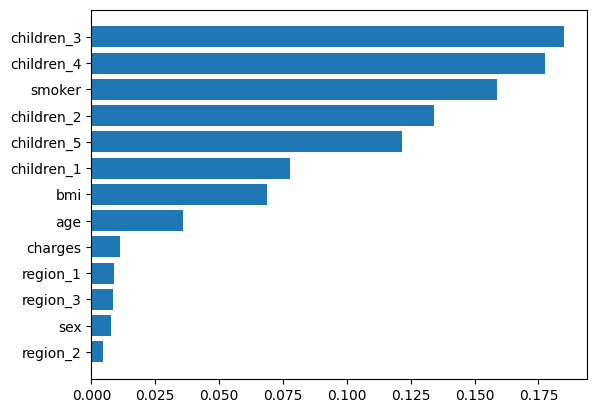

In [88]:
# Building Extreme Gradient Boosting Classifier

XGB_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False)#.fit(Train_X_std, Train_Y, eval_metric='logloss')

param_dist = {
 "learning_rate" : [0.05,0.10,0.15,0.20,0.25,0.30],
 "max_depth" : [ 3, 4, 5, 6, 8, 10, 12, 15],
 "min_child_weight" : [ 1, 3, 5, 7 ],
 "gamma": [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]
}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

#RCV = RandomizedSearchCV(XGB_model, param_dist, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5, random_state=1)

XGB = XGB_model.fit(Train_X_std, Train_Y)#.best_estimator_
pred = XGB.predict(Test_X_std)
pred_prob = XGB.predict_proba(Test_X_std)
Classification_Summary(pred,pred_prob,7)

xgbf=pd.DataFrame(XGB.feature_importances_, index=Train_X_std.columns).sort_values(by=0)
plt.barh(xgbf.index,xgbf.values[:,0])
plt.show()

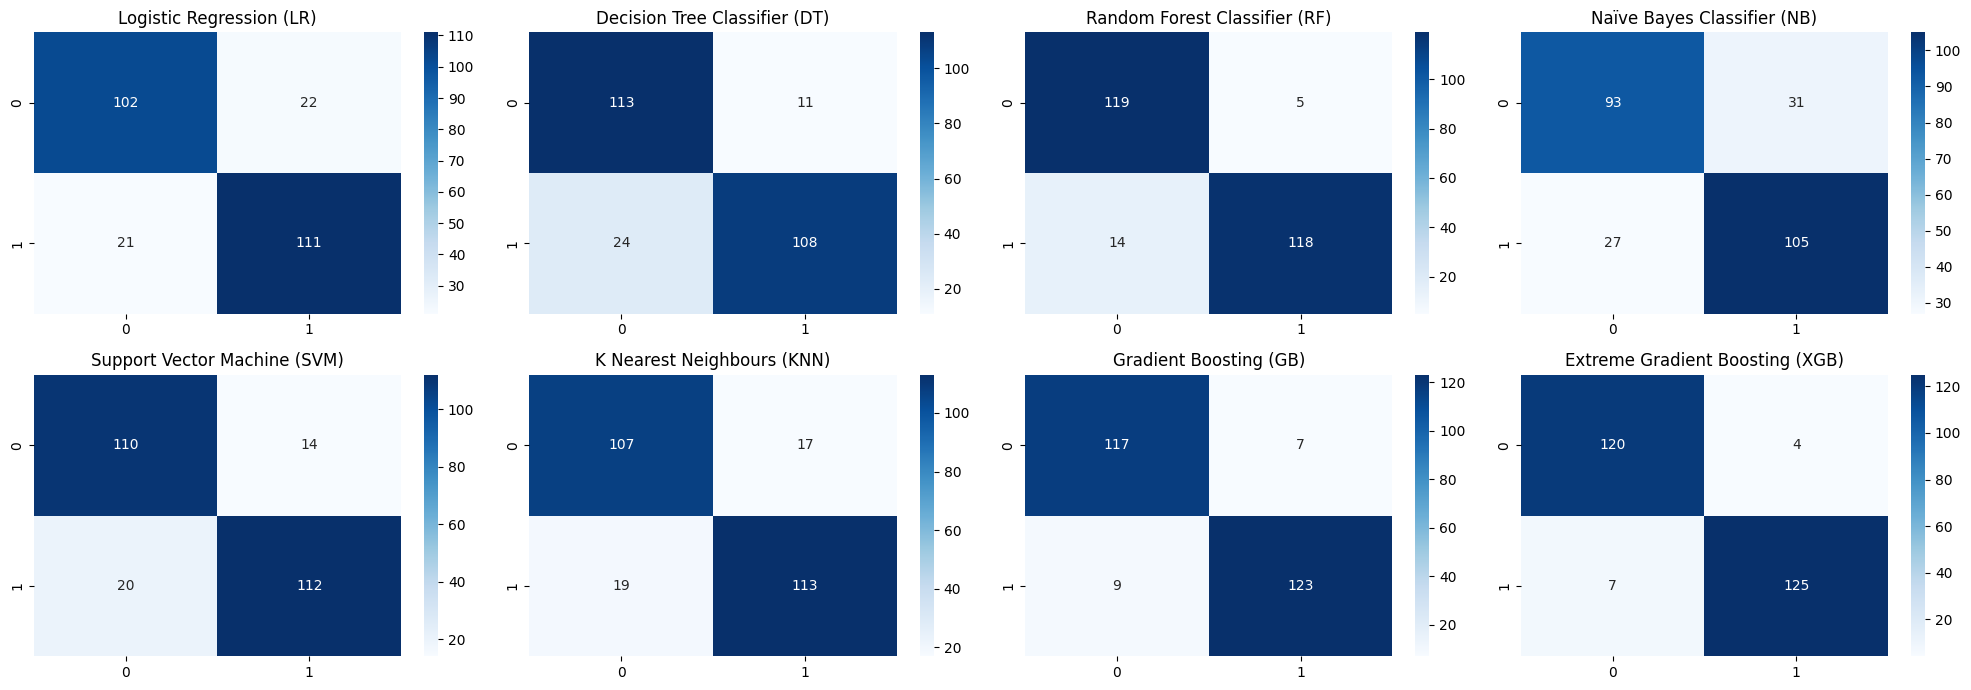

In [89]:
#Plotting Confusion-Matrix of all the predictive Models

def plot_cm(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=np.unique(y_true), columns=np.unique(y_true))
    cm.columns=labels
    cm.index=labels
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    #fig, ax = plt.subplots()
    sns.heatmap(cm, annot=annot, fmt='')# cmap= "GnBu"
    
def conf_mat_plot(all_models):
    plt.figure(figsize=[20,3.5*math.ceil(len(all_models)*len(labels)/14)])
    
    for i in range(len(all_models)):
        if len(labels)<=4:
            plt.subplot(2,4,i+1)
        else:
            plt.subplot(math.ceil(len(all_models)/3),3,i+1)
        pred = all_models[i].predict(Test_X_std)
        #plot_cm(Test_Y, pred)
        sns.heatmap(confusion_matrix(Test_Y, pred), annot=True, cmap='Blues', fmt='.0f') #vmin=0,vmax=5
        plt.title(Evaluation_Results.index[i])
    plt.tight_layout()
    plt.show()

conf_mat_plot([LR,DT,RF,NB,SVM,KNN,GB,XGB])


                                    ML Algorithms Comparison                                    


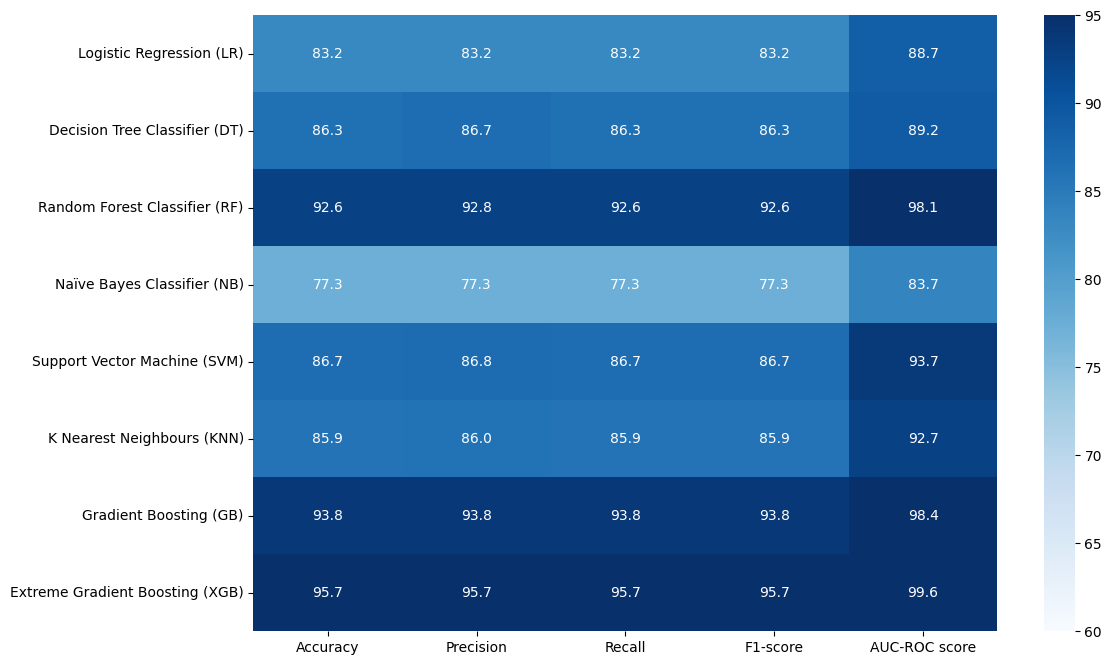

In [90]:
print('\033[1mML Algorithms Comparison'.center(100))
plt.figure(figsize=[12,8])
sns.heatmap(Evaluation_Results, annot=True, vmin=60, vmax=95, cmap='Blues', fmt='.1f')
plt.show()

Insights: For the current problem statement, it is more important to focus on the F1-score. Except Naive Baye's Classifier, most of the algorithms perform well. The best performing algorithm is Extreme Gradient Boosting Classifier...

## 7. Project Outcomes & Conclusions

Here are some of the key outcomes of the project:

The Dataset was small totally around 1338 samples & after preprocessing 17% of the datasamples were dropped.
The samples were highly imbalanced, hence SMOTE Technique was applied on the data to balance the classes, adding 5.5% more samples to the dataset.
Visualising the distribution of data & their relationships, helped us to get some insights on the relationship between the featureset.
Feature Selection/Eliminination was carried out and appropriate features were shortlisted.
Testing multiple algorithms with fine-tuning hyperparamters gave us some understanding on the model performance for various algorithms on this specific dataset.
The boosting & ensemble algorithms perform the best on the current dataset, followed by Nearest Neighbours Algorithm.
Yet it wise to also consider simpler model like Logistic Regression as it is more generalisable & is computationally less expensive.